# Experiment 5 — GP Baseline-Identifiability (fit to Bays)

## What this notebook is

This is a **GP-model** experiment, not a Bays self-fit. It fits *our* population
model (`generate_neuron_population` + `run_multiloc_trials`) to the **fixed
M=100 Bays reference cache** — exactly the target every other experiment fits
to — and then **sweeps an added baseline floor** `f₀` to reproduce Bays's
identifiability result:

> The behavioural error distribution cannot pin down the gain `γ` on its own.
> It pins down only the **signal-to-noise ratio per neuron**. Adding
> stimulus-independent baseline activity shifts the ML-fitted `γ` upward by
> orders of magnitude while the error distribution stays put, because
> `(γ, ω, f₀)` trade off along an iso-SNR ridge.

### How it differs from `experiment_4_5`

The old Figure-5 block fit the **Bays parametric model to a Bays-generated
synthetic reference** using the shared-kernel infrastructure borrowed from
Figure 4. That shared kernel was a *Figure-4 robustness device* (homogeneous
populations); it has no place here. In this notebook:

- **`M`, `DISTRIBUTION`, `MODEL` are live** — the population is built by
  `generate_neuron_population`, so `DISTRIBUTION` genuinely sets how per-location
  tuning widths are sampled and `M` sets the population the GP model is fit with.
- The **fit target is fixed**: the M=100 Bays cache, loaded once via
  `load_bays_cache`.
- The **swept variable** is the baseline fraction `f₀` (not fitted).
- Outputs land in `result_data/experiment_5/<date>/<dist>_<M>_<model>/<time>`,
  matching experiment_2's layout.

### The fitted parameters and where the lengthscales come from

The fit's three free numbers are `(width, gamma_per_neuron, sigma)`. For
`MODEL='gp'`, `width` is the **base** lengthscale (the *centre* of the
distribution) and `sigma` is its spread; the actual per-location `λᵢ` are
**sampled from `DISTRIBUTION`** around that base on every evaluation. So we fit
the distribution's parameters against Bays; the individual lengthscales are
drawn from it.

## Setup

In [1]:
# Setup for the Notebook
import sys
from pathlib import Path

# Match experiment_2: project root is two levels up from the notebook.
PROJECT_ROOT = str(Path.cwd().parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import time
import datetime
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import least_squares

# GP framework (identical import surface to experiment_2)
from core.encoder.gaussian_process import generate_neuron_population
from core.population import run_multiloc_trials
from core.metrics import circular_moments

# Bays cache loader — single source of truth for the fit TARGET
from experiments.bays_cache import load_bays_cache

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1


## Configuration — load the fixed Bays target

The fit target is the canonical **M=100** Bays cache. Its generating parameters
are read straight off the cache metadata, so there is no second copy of the
Bays constants to drift out of sync.

In [2]:
# === Notebook configuration ===
M_BAYS_REF = 100
bays_errors, bays_meta = load_bays_cache(M=M_BAYS_REF)   # loader defaults -> canonical cache

OMEGA_BAYS       = bays_meta['omega']
GAMMA_TOTAL_BAYS = bays_meta['gamma_total']
T_D              = bays_meta['T_d']
SEED             = bays_meta['seed']

# Genuine notebook-side config (NOT stored in the cache)
N_THETA  = 128
SIGMA_SQ = 1e-6

print('=== Fit target (fixed Bays reference) ===')
print(f'  cache       = {bays_meta["cache_filename"]}  (fixed M={M_BAYS_REF})')
print(f'  omega       = {OMEGA_BAYS}')
print(f'  gamma_total = {GAMMA_TOTAL_BAYS} Hz')
print(f'  T_d         = {T_D} s   seed = {SEED}')

=== Fit target (fixed Bays reference) ===
  cache       = bays_cache_omega0.52_gamma119_M100_N10000_seed12345.npz  (fixed M=100)
  omega       = 0.52
  gamma_total = 119.0 Hz
  T_d         = 0.1 s   seed = 12345


## Experiment Control

The single source of truth for the run. Unlike the Figure-4 notebook, these
knobs are **functional**: `MODEL` / `DISTRIBUTION` flow into
`generate_neuron_population`, and `M` sets the fitted population's size.

In [3]:
# === EXPERIMENT CONTROL (M / DISTRIBUTION / MODEL) — live, mirrors experiment_2 ===
M            = 1000               # GP/VM population size (100 is much faster)
DISTRIBUTION = 'gamma'            # 'folded_normal' | 'gamma' | 'sparse_sharp'
MODEL        = 'gp'               # 'gp' | 'vm' | 'bays'

# sparse_sharp knobs (ignored unless DISTRIBUTION == 'sparse_sharp')
N_HIGH          = 1
HIGH_MULTIPLIER = 3.0

# Amplitude variability (0 to match the homogeneous Bays reference)
GAIN_VARIABILITY = 0.0

assert DISTRIBUTION in ('folded_normal', 'gamma', 'sparse_sharp'), DISTRIBUTION
assert MODEL in ('gp', 'vm', 'bays'), MODEL

# --- ONE shared output directory (experiment_2-style layout) ---
#   result_data / experiment_5 / <date> / <distribution>_<M>_<model> / <time>
EXPERIMENT_TAG = 'experiment_5'
_date = datetime.datetime.now().strftime('%Y%m%d')
_time = datetime.datetime.now().strftime('%H%M%S')
RESULT_BASE = Path(PROJECT_ROOT) / 'experiments' / 'bays_2014' / 'result_data'
OUTPUT_DIR  = (RESULT_BASE / EXPERIMENT_TAG / _date /
               f'{DISTRIBUTION}_{M}_{MODEL}' / _time)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('=== Experiment control (global) ===')
print(f'  M            = {M}')
print(f'  DISTRIBUTION = {DISTRIBUTION!r}')
print(f'  MODEL        = {MODEL!r}')
if DISTRIBUTION == 'sparse_sharp':
    print(f'  N_HIGH={N_HIGH}  HIGH_MULTIPLIER={HIGH_MULTIPLIER}')
print(f'  Bays target  = fixed M={M_BAYS_REF} (decoupled from model M)')
print(f'  OUTPUT_DIR   = {OUTPUT_DIR}')

=== Experiment control (global) ===
  M            = 1000
  DISTRIBUTION = 'gamma'
  MODEL        = 'gp'
  Bays target  = fixed M=100 (decoupled from model M)
  OUTPUT_DIR   = /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/experiment_5/20260830/gamma_1000_gp/203023


## Population builder with a baseline floor

`build_population` is experiment_2's dispatcher, **extended with a
`baseline_frac` knob**. The baseline is a stimulus-independent floor added to
the driving input `g = exp(f)` **before** divisive normalization, following
Bays's *fraction-of-peak* convention (Bays 2014, Eq. 14 / Fig 5):

$$ f_0 = \text{baseline\_frac} \cdot \frac{\overline{\text{peak}}}{1 - \text{baseline\_frac}}, \qquad g \leftarrow g + f_0 $$

where $\overline{\text{peak}}$ is the population-mean of the per-(neuron,
location) maximum driving input. `baseline_frac = 0` is a no-op. This is the
**swept** variable of Experiment 5 — it is never fitted.

In [4]:
# === Population builder (experiment_2 dispatcher + baseline floor) ===
SET_SIZES = [1, 2, 4, 8]   # Bays-literal set sizes for the fit target

def _inject_baseline(f_all, baseline_frac):
    """Add a constant floor f0 to the driving input g=exp(f) at every location.

    f0 is set so f0/(f0+peak)=baseline_frac, with `peak` the population mean of
    the per-(neuron,location) max driving input. Returns new log-tuning arrays
    log(exp(f)+f0). baseline_frac<=0 is a no-op.
    """
    if baseline_frac <= 1e-12:
        return f_all
    if baseline_frac >= 1.0:
        raise ValueError('baseline_frac must be < 1 (fraction of peak)')
    peaks = [np.max(np.exp(f), axis=1) for f in f_all]     # list of (M,)
    mean_peak = float(np.mean(np.concatenate(peaks)))
    f0 = baseline_frac * mean_peak / (1.0 - baseline_frac)
    return [np.log(np.exp(f) + f0) for f in f_all]

def build_population(width, sigma, seed, baseline_frac=0.0):
    """Assemble a population under the global MODEL / DISTRIBUTION, then add the
    baseline floor.

    `width` is interpreted per MODEL:
        MODEL='gp'             -> GP base lengthscale (lambda); omega = lambda**2
        MODEL in ('vm','bays') -> Von Mises width (omega) directly

    Returns (thetas, f_all) with f_all a list over locations of (M, n_theta)
    log-tuning arrays, ready for run_multiloc_trials.
    """
    max_locs = max(SET_SIZES)
    kw = dict(
        n_neurons=M, n_orientations=N_THETA, n_locations=max_locs,
        base_lengthscale=width, lengthscale_variability=sigma,
        seed=seed, gain_variability=GAIN_VARIABILITY, model=MODEL,
    )
    if MODEL in ('gp', 'vm'):
        kw['method'] = DISTRIBUTION
        if DISTRIBUTION == 'sparse_sharp':
            kw.update(n_high=N_HIGH, high_multiplier=HIGH_MULTIPLIER)
    if MODEL in ('vm', 'bays'):
        kw['omega'] = width          # width is omega for VM / Bays

    population = generate_neuron_population(**kw)
    thetas = population[0]['orientations']
    f_all = [np.array([population[n]['f_samples'][loc, :] for n in range(M)])
             for loc in range(max_locs)]
    f_all = _inject_baseline(f_all, baseline_frac)
    return thetas, f_all

## Fit configuration

Same optimiser setup as experiment_2 — least_squares on concatenated histogram
residuals over set sizes {1, 2, 4, 8} — plus the **baseline sweep** list. The
`gamma` upper bound is deliberately generous: baseline activity drives the
fitted gain up by orders of magnitude (Bays Fig 5a spans 10² – 10⁶ Hz total).

In [5]:
# === Fit configuration ===
N_TRIALS_FIT = 1000    # GP forward-model trials per fit evaluation
N_BINS_FIT   = 50
BIN_EDGES    = np.linspace(-np.pi, np.pi, N_BINS_FIT + 1)
BIN_CENTERS  = 0.5 * (BIN_EDGES[:-1] + BIN_EDGES[1:])
SEED_FIT     = SEED + 9000

# --- Baseline sweep (the Experiment-5 variable; NOT fitted) ---
# Bays uses {0, 5, 20, 50, 80, 95}%. Higher baselines push the fitted gain very
# high and make the fit slower; this four-point default keeps runtime sane.
# Extend toward Bays's six-point sweep once you are happy with timing.
BASELINE_FRACS = [0.0, 0.25, 0.50, 0.75]

# --- Optimiser start / bounds: (width, gamma_per_neuron, sigma) ---
# gamma is PER NEURON; gamma_total = gamma * M.
GAMMA_HI_TOTAL = 2.0e6                      # allow gamma_total up to ~2e6 Hz
if DISTRIBUTION == 'folded_normal':
    X0 = [1.0, GAMMA_TOTAL_BAYS / M, 0.5]
    LO = [0.1, 1e-4,                 0.0]
    HI = [3.0, GAMMA_HI_TOTAL / M,   2.0]
    SIGMA_NAME = 'sigma_lambda'
else:  # 'gamma' / 'sparse_sharp' use a strictly-positive CV-like spread
    X0 = [1.0, GAMMA_TOTAL_BAYS / M, 0.5]
    LO = [0.1, 1e-4,                 0.01]
    HI = [3.0, GAMMA_HI_TOTAL / M,   10.0]
    SIGMA_NAME = 'cv'
DIFF_STEP = 0.05

# --- Fit target: histogram the fixed Bays errors over the four set sizes ---
data_hists = {}
for N in SET_SIZES:
    h, _ = np.histogram(bays_errors[N], bins=BIN_EDGES, density=True)
    data_hists[N] = h
data_vector = np.concatenate([data_hists[N] for N in SET_SIZES])

print(f'Set sizes:   {SET_SIZES}')
print(f'Baselines:   {[int(b*100) for b in BASELINE_FRACS]}%')
print(f'x0 = (width, gamma_pn, {SIGMA_NAME}) = {X0}')
print(f'gamma_total bounds: [{LO[1]*M:.1f}, {HI[1]*M:.0f}] Hz')
print(f'Data vector: {data_vector.shape}')

Set sizes:   [1, 2, 4, 8]
Baselines:   [0, 25, 50, 75]%
x0 = (width, gamma_pn, cv) = [1.0, 0.119, 0.5]
gamma_total bounds: [0.1, 2000000] Hz
Data vector: (200,)


## Fit machinery

`fit_at_baseline(f₀)` runs one least_squares fit of `(width, gamma_per_neuron,
sigma)` against the fixed Bays target, with the baseline baked into every
population it builds. The forward model and trial engine are the core modules —
nothing is reimplemented here. The population is cached on `(width, sigma,
seed)` so the gamma Jacobian column doesn't rebuild an identical population.

In [6]:
# === Unified fit at a fixed baseline (mirrors experiment_2's fit loop) ===
def _make_forward(baseline_frac):
    """Return a forward model bound to this baseline, with a population cache."""
    pop_cache = {}
    def _cached_population(width, sigma, seed):
        key = (round(float(width), 6), round(float(sigma), 6), int(seed))
        pop = pop_cache.get(key)
        if pop is None:
            pop = build_population(width, sigma, seed, baseline_frac=baseline_frac)
            pop_cache[key] = pop
        return pop
    def forward(width, gamma_pn, sigma, seed=0):
        thetas, f_all = _cached_population(width, sigma, seed)
        pred = []
        for N in SET_SIZES:
            rng = np.random.RandomState(seed + N)
            errs = run_multiloc_trials(
                f_all, thetas, tuple(range(N)), 0,
                gamma_pn, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
            h, _ = np.histogram(errs, bins=BIN_EDGES, density=True)
            pred.append(h)
        return np.concatenate(pred)
    return forward

def fit_at_baseline(baseline_frac):
    """Least-squares fit of (width, gamma_pn, sigma) at one baseline.

    Returns a dict of fitted params plus the fitted (thetas, f_all) so the SNR
    and error-distribution panels can reuse the exact fitted population.
    """
    forward = _make_forward(baseline_frac)
    def residual(p):
        width, gamma_pn, sigma = p
        return data_vector - forward(width, gamma_pn, sigma, seed=SEED_FIT)
    res = least_squares(residual, x0=X0, bounds=(LO, HI),
                        method='trf', diff_step=DIFF_STEP, verbose=0)
    width_hat, gamma_pn_hat, sigma_hat = res.x
    omega_hat = width_hat ** 2 if MODEL == 'gp' else width_hat
    thetas_fit, f_all_fit = build_population(
        width_hat, sigma_hat, SEED_FIT, baseline_frac=baseline_frac)
    return {
        'baseline':    baseline_frac,
        'width':       width_hat,
        'gamma_pn':    gamma_pn_hat,
        'gamma_total': gamma_pn_hat * M,
        'omega':       omega_hat,
        'sigma':       sigma_hat,
        'cost':        float(res.cost),
        'edge_gamma':  bool(gamma_pn_hat >= HI[1] * 0.999),
        'thetas':      thetas_fit,
        'f_all':       f_all_fit,
    }

## GP-appropriate SNR-per-neuron

Bays reports SNR for a population encoding a **single stimulus** (Fig 5d). His
Eq. 16 is closed-form for Von Mises tuning and does **not** transfer to a
heterogeneous GP population, so we compute the *same quantity* empirically. For
each neuron the post-DN rate $r_i(\theta)$ is evaluated across the uniform
orientation ensemble, and

$$ \mathrm{SNR}_i = \frac{\mathrm{Var}_\theta[\, r_i(\theta)\,T_d \,]}{\mathbb{E}_\theta[\, r_i(\theta)\,T_d \,]} $$

(stimulus-driven variance over Poisson variance, since Poisson variance = mean).
We report the mean over neurons. This reduces to Bays Eq. 15 for homogeneous
Von Mises tuning, and is the invariant the behavioural data actually pin down.

In [7]:
# === Empirical SNR-per-neuron at set size 1 ===
def gp_snr_per_neuron(thetas, f_all, gamma_pn, T_d, sigma_sq, loc=0):
    """Mean SNR-per-neuron for a single item at `loc`, over the theta ensemble."""
    g = np.exp(f_all[loc])                      # (M, n_theta) driving input
    D = sigma_sq + np.mean(g, axis=0)           # (n_theta,) DN denominator
    r_post = gamma_pn * g / D[np.newaxis, :]    # (M, n_theta) post-DN rates
    lam = r_post * T_d                          # expected spike counts
    signal = np.var(lam, axis=1)                # stimulus-driven variance / neuron
    noise  = np.mean(lam, axis=1)               # Poisson variance = mean
    snr = np.divide(signal, noise,
                    out=np.zeros_like(signal), where=noise > 0)
    return float(np.mean(snr))

## Run the baseline sweep

One full fit per baseline against the **same** fixed Bays target. For each we
record the fitted gain / width / spread and the empirical SNR-per-neuron, and
stash a pool of fitted-model errors for the distribution panel.

In [8]:
# === Run the baseline sweep ===
N_TRIALS_SHOW = 5000    # fitted-model errors for the distribution panel

results = []
t0 = time.time()
for bf in BASELINE_FRACS:
    tk = time.time()
    fit = fit_at_baseline(bf)
    fit['snr'] = gp_snr_per_neuron(
        fit['thetas'], fit['f_all'], fit['gamma_pn'], T_D, SIGMA_SQ)

    # Fitted-model error pool + moments (for panel c and a sanity print).
    fitted_errors = {}
    for N in SET_SIZES:
        rng = np.random.RandomState(SEED_FIT + 7000 + N)
        fitted_errors[N] = run_multiloc_trials(
            fit['f_all'], fit['thetas'], tuple(range(N)), 0,
            fit['gamma_pn'], T_D, SIGMA_SQ, N_TRIALS_SHOW, rng)
    fit['fitted_errors'] = fitted_errors
    var4 = circular_moments(fitted_errors[4])['variance']

    results.append(fit)
    edge = '  [gamma at upper bound]' if fit['edge_gamma'] else ''
    print(f'  baseline={bf*100:>5.1f}%:  '
          f'gamma_total={fit["gamma_total"]:>12.1f} Hz   '
          f'omega={fit["omega"]:.3f}   {SIGMA_NAME}={fit["sigma"]:.3f}   '
          f'SNR={fit["snr"]:.4f}   var(l=4)={var4:.3f}   '
          f'cost={fit["cost"]:.5f}   ({time.time()-tk:.1f}s){edge}')
print(f'\nSweep done in {time.time()-t0:.1f}s')

  baseline=  0.0%:  gamma_total=       118.0 Hz   omega=1.205   cv=0.493   SNR=0.0073   var(l=4)=0.341   cost=1.10188   (406.4s)
  baseline= 25.0%:  gamma_total=       121.7 Hz   omega=1.075   cv=0.509   SNR=0.0023   var(l=4)=1.138   cost=1.34844   (223.5s)
  baseline= 50.0%:  gamma_total=       121.2 Hz   omega=1.018   cv=0.518   SNR=0.0007   var(l=4)=2.250   cost=3.59227   (298.3s)
  baseline= 75.0%:  gamma_total=       121.8 Hz   omega=1.169   cv=0.519   SNR=0.0001   var(l=4)=4.010   cost=5.85396   (372.1s)

Sweep done in 1300.4s


## Log the sweep to CSV

One row per baseline, written into this run's output directory alongside the
figure.

In [9]:
# === Log the sweep to CSV ===
csv_path = OUTPUT_DIR / 'experiment_5_baseline_sweep.csv'
with open(csv_path, 'w', newline='') as fh:
    w = csv.writer(fh)
    w.writerow(['baseline_frac', 'M', 'model', 'distribution',
                'width', 'omega', 'gamma_pn', 'gamma_total',
                SIGMA_NAME, 'snr_per_neuron', 'cost', 'edge_gamma'])
    for r in results:
        w.writerow([r['baseline'], M, MODEL, DISTRIBUTION,
                    r['width'], r['omega'], r['gamma_pn'], r['gamma_total'],
                    r['sigma'], r['snr'], r['cost'], int(r['edge_gamma'])])
print(f'Wrote {csv_path}')

Wrote /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/experiment_5/20260830/gamma_1000_gp/203023/experiment_5_baseline_sweep.csv


## Figure — the four-panel identifiability result

Aesthetics follow the project's Bays (2014) Fig 5 convention: per-panel titles, bold panel labels, top/right spines removed, log y-axes with decimal tick labels, and baseline 0% drawn as an isolated marker before the connected line (y-limits autoscale, since the GP model's gain/SNR sit on a different scale than Bays's parametric ranges).

- **(a)** fitted `γ_total` climbs orders of magnitude with baseline;
- **(b)** fitted `ω` drifts up mildly;
- **(c)** predicted error distributions, KDE-smoothed and **overlaid by baseline** (one colour per baseline; all set sizes {1,2,4,8}, with the set size labelled at each peak of the baseline-0 curve) — the curves lie on top of one another, i.e. behaviour is invariant;
- **(d)** SNR-per-neuron is flat — the quantity the data actually constrain.


Saved /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/experiment_5/20260830/gamma_1000_gp/203023/experiment_5_baseline_identifiability_M1000.png
Saved /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/experiment_5/20260830/gamma_1000_gp/203023/experiment_5_baseline_identifiability_M1000.pdf


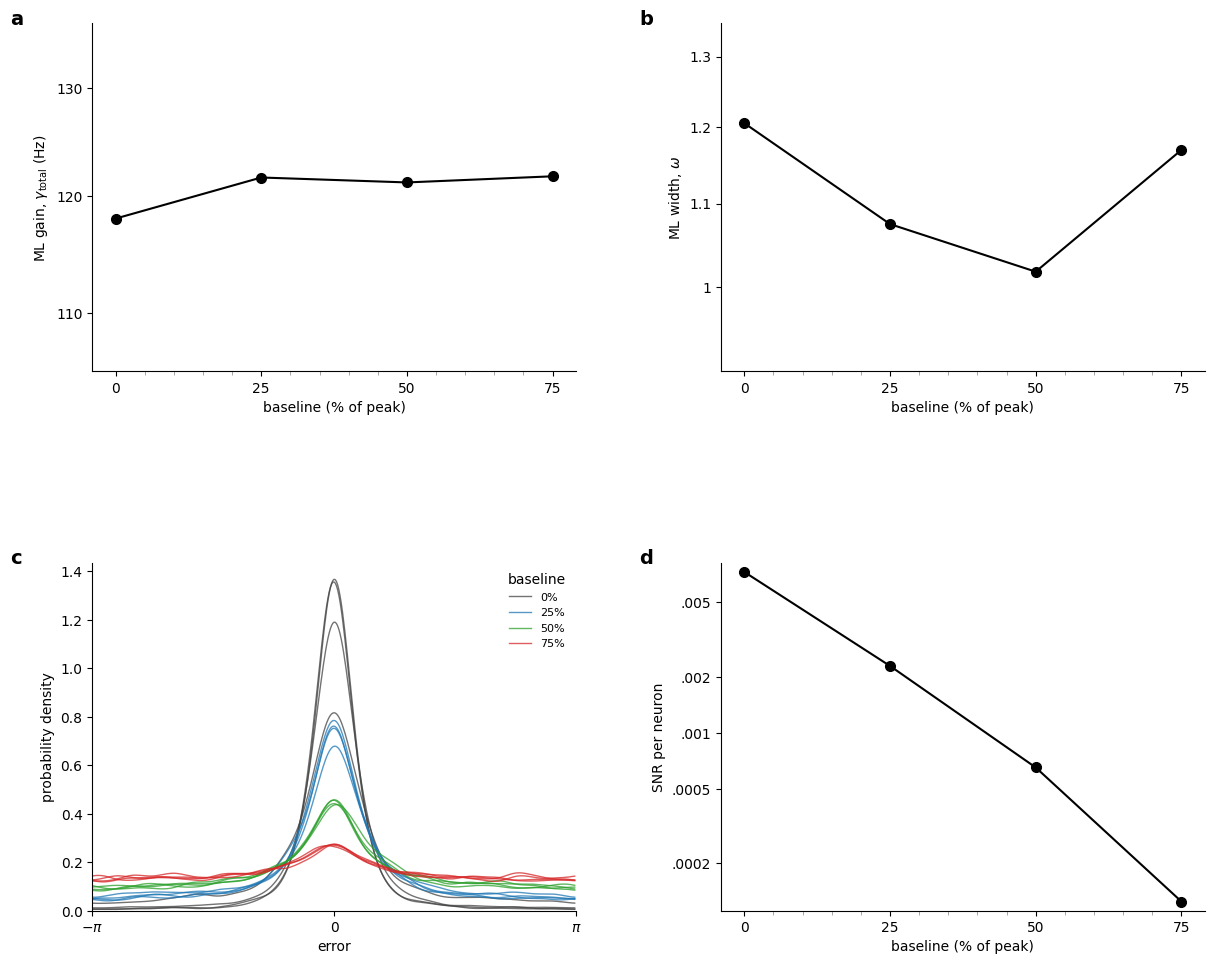

In [10]:
# === Figure: Experiment 5 (GP baseline identifiability) ===
from scipy.special import i0
from matplotlib.ticker import FuncFormatter, FixedLocator, MaxNLocator

fig = plt.figure(figsize=(12.5, 10.5))
gs = gridspec.GridSpec(2, 2, hspace=0.55, wspace=0.30,
                       left=0.085, right=0.975, bottom=0.075, top=0.92)
ax_a = fig.add_subplot(gs[0, 0]); ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0]); ax_d = fig.add_subplot(gs[1, 1])

# results are in ascending-baseline order; index 0 is baseline 0.
res_by_b = {r['baseline']: r for r in results}
x_pct  = np.array([r['baseline'] * 100 for r in results])
gammas = np.array([r['gamma_total'] for r in results])
omegas = np.array([r['omega']       for r in results])
snrs   = np.array([r['snr']         for r in results])

# One marker per sampled baseline, joined by a line (no zero-break).
LINE_KW = dict(color='black', marker='o', ms=7, lw=1.5, zorder=2)

def _decimal_fmt(v, _pos):
    """Strip the leading zero from decimal tick labels (0.25 -> .25)."""
    if v <= 0:
        return ''
    s = ('%g' % v)
    return s[1:] if s.startswith('0.') else s

def _log_ticks(ylo, yhi):
    """Complete, uncrowded ticks: 1-2-5 per decade for wide ranges, linear-nice
    ticks for sub-decade (near-flat) ranges so labels never collapse to one."""
    dec = np.log10(yhi) - np.log10(ylo)
    if dec < 1.0:
        t = MaxNLocator(nbins=5, steps=[1, 2, 2.5, 5, 10]).tick_values(ylo, yhi)
    else:
        mult = (1,) if dec >= 4 else (1, 3) if dec >= 2 else (1, 2, 5)
        kmin, kmax = int(np.floor(np.log10(ylo))), int(np.ceil(np.log10(yhi)))
        t = [m * 10.0**k for k in range(kmin, kmax + 1) for m in mult]
    t = np.asarray(t, float)
    return t[(t >= ylo) & (t <= yhi)]

def style_log_y(ax, vals, pad=1.12):
    """Log y with limits hugging the data and a complete set of ticks."""
    ax.set_yscale('log')
    vals = np.asarray(vals, float); vals = vals[vals > 0]
    ylo, yhi = vals.min() / pad, vals.max() * pad
    ax.set_ylim(ylo, yhi)
    ax.yaxis.set_major_locator(FixedLocator(_log_ticks(ylo, yhi)))
    ax.yaxis.set_major_formatter(FuncFormatter(_decimal_fmt))
    ax.minorticks_off()

def style_baseline_axis(ax, label):
    ax.set_xlabel('baseline (% of peak)')
    ax.set_xticks(x_pct)                                   # majors = sampled baselines (labeled)
    ax.set_xticklabels([f'{int(v)}' for v in x_pct])
    ax.set_xticks(np.arange(0, 81, 5), minor=True)         # minors every 5% (unlabeled)
    ax.set_xlim(x_pct.min() - 4, x_pct.max() + 4)
    ax.tick_params(axis='x', which='minor', length=3, color='#999999')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.text(-0.17, 1.04, label, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top')

# ---- Panel a: gamma_total ----
ax_a.plot(x_pct, gammas, **LINE_KW)
style_log_y(ax_a, gammas)
ax_a.set_ylabel(r'ML gain, $\gamma_{\mathrm{total}}$ (Hz)')
style_baseline_axis(ax_a, r'$\mathbf{a}$')

# ---- Panel b: omega ----
ax_b.plot(x_pct, omegas, **LINE_KW)
style_log_y(ax_b, omegas)
ax_b.set_ylabel(r'ML width, $\omega$')
style_baseline_axis(ax_b, r'$\mathbf{b}$')

# ---- Panel c: error distributions across set sizes, baselines overlaid ----
def _vm_kde(errors, eval_pts, kappa):
    d = eval_pts[:, None] - errors[None, :]
    log_w = kappa * np.cos(d)
    m = log_w.max(axis=1, keepdims=True)
    w = np.exp(log_w - m)
    return (w.mean(axis=1) * np.exp(m.squeeze())) / (2.0 * np.pi * i0(kappa))

PANEL_C_BASELINES = list(BASELINE_FRACS)
PANEL_C_SET_SIZES = [N for N in (1, 2, 4, 8) if N in SET_SIZES]
_palette = ['#444444', '#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
PANEL_C_COLORS = {bf: _palette[i % len(_palette)]
                  for i, bf in enumerate(PANEL_C_BASELINES)}
KAPPA_KDE_PANEL_C = 50.0
eval_pts = np.linspace(-np.pi, np.pi, 400, endpoint=False)

for bf in PANEL_C_BASELINES:
    color = PANEL_C_COLORS[bf]
    for l in PANEL_C_SET_SIZES:
        errs = res_by_b[bf]['fitted_errors'][l]
        density = _vm_kde(errs, eval_pts, KAPPA_KDE_PANEL_C)
        ax_c.plot(eval_pts, density, color=color, lw=1.0, alpha=0.75,
                  label=f'{int(bf*100)}%' if l == PANEL_C_SET_SIZES[0] else None)

ax_c.set_xlim(-np.pi, np.pi)
ax_c.set_xticks([-np.pi, 0, np.pi])
ax_c.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
ax_c.set_ylim(bottom=0)
ax_c.set_xlabel('error')
ax_c.set_ylabel('probability density')
ax_c.legend(fontsize=8, frameon=False, loc='upper right', title='baseline')
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)
ax_c.text(-0.17, 1.04, r'$\mathbf{c}$', transform=ax_c.transAxes,
          fontsize=14, fontweight='bold', va='top')

# ---- Panel d: SNR ----
ax_d.plot(x_pct, snrs, **LINE_KW)
style_log_y(ax_d, snrs)
ax_d.set_ylabel('SNR per neuron')
style_baseline_axis(ax_d, r'$\mathbf{d}$')

_png = OUTPUT_DIR / f'experiment_5_baseline_identifiability_M{M}.png'
_pdf = OUTPUT_DIR / f'experiment_5_baseline_identifiability_M{M}.pdf'
fig.savefig(_png, dpi=300, bbox_inches='tight')
fig.savefig(_pdf, bbox_inches='tight')
print(f'Saved {_png}')
print(f'Saved {_pdf}')
plt.show()